In [ ]:
2 + 2

4

In [2]:
import os
from pathlib import Path

from IPython.display import display, HTML, clear_output
from PIL import Image
from dotenv import load_dotenv

load_dotenv()

from cropgen.external_interfaces.LabelStudioInterface import LabelStudioInterface
from cropgen.processing.AnnotatedPage import AnnotatedPage
from cropgen.shared.PathBundle import PathBundle
from cropgen.external_interfaces.OracleBucketInterface import OracleBucketInterface

paths = PathBundle(Path(os.getcwd()).parents[2])
obi = OracleBucketInterface(paths)
# obi.update()
# LabelStudioInterface.update_conditional(paths)
lsi = LabelStudioInterface(paths)

from cropgen.tests.tests_helper import load_ann, task_from_task_id

In [55]:
from cropgen.tests.processing.test_regex import number_of_matches
import re

str_to_find = r"de catégories. Ce qui lui manque pour l'être,"

number_of_matches(re.escape(str_to_find))

Matches in <Annotation of task 644 of order 24. Completed by navarro, last updated by claudia.dominguez at 2026-02-28 07:58:13.239374> for pattern de\ catégor\ l'être,:
	de catégories. Ce qui lui manque pour l'être,
	^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[1]

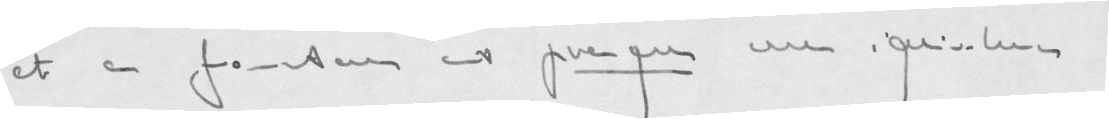

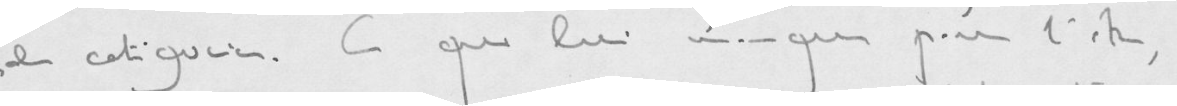

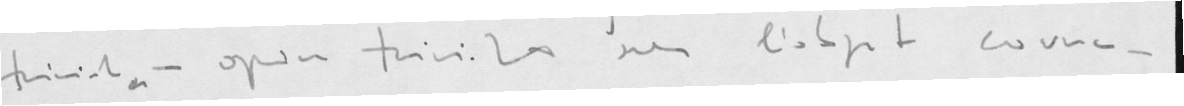

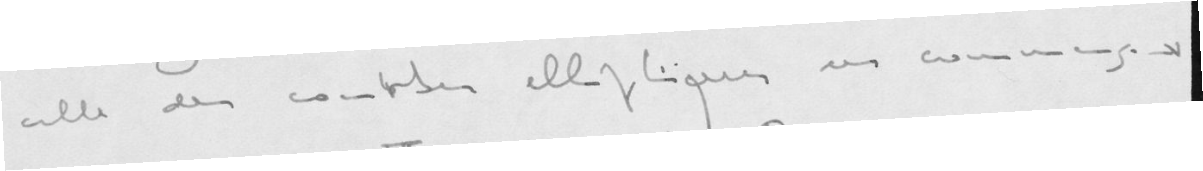

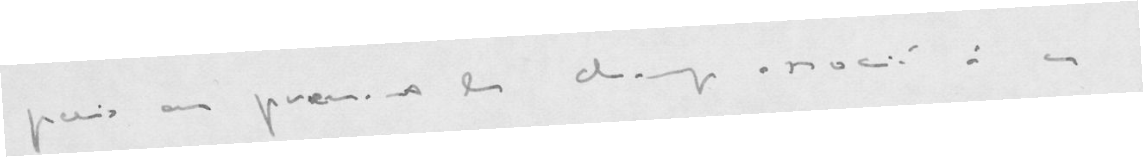

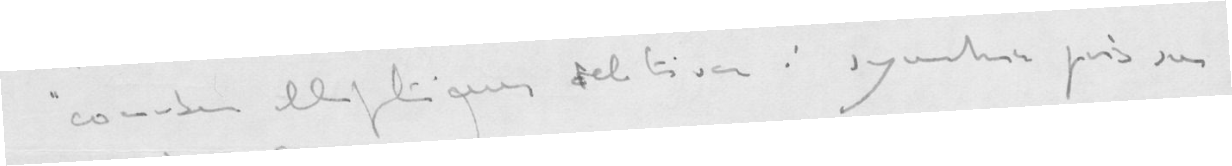

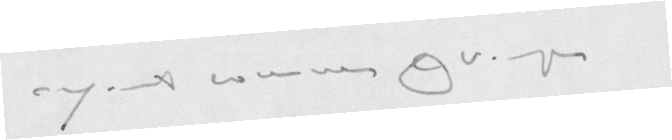

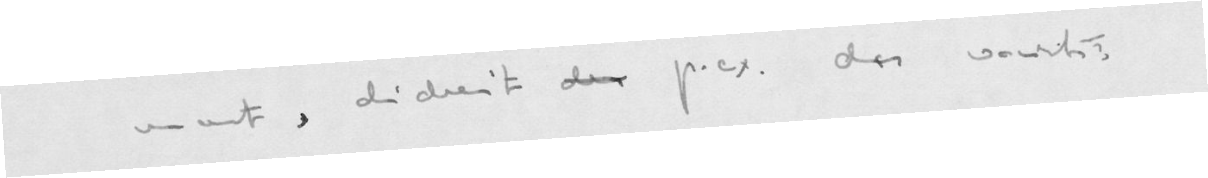

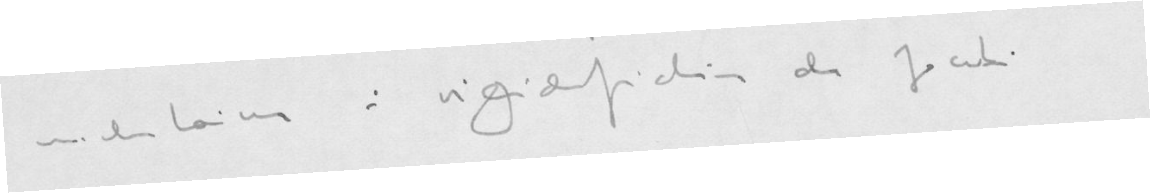

In [59]:
task_id = 644
annotation_number_in_task = 0


# task_id = 12
# annotation_number_in_task = 0
task = task_from_task_id(lsi, task_id)
img = Image.open(paths.get_image_path_from_task(task))


ann = load_ann(paths, task_id, annotation_number_in_task, unrotate=False)


par = lambda k: ann.paragraphs[k].image_boxes_ids

all_in_page = list(ann.image_boxes.keys())
comilla = '"'
for fragment in ann.text_fragments.values():

    if "$" not in fragment.text:
        display(fragment.box.crop)
        fragment.box.crop.save(
            Path(
                rf"C:\Users\pambi\Documents\1Universidad\TFG\Memoria - typst\assets\Modelo y entrenamiento\{fragment.text[:10].replace(comilla, '')}.png"
            )
        )

In [13]:
ann

<Annotation of task 328 of order 21. Completed by pambignacio8, last updated by pambignacio8 at 2026-04-27 15:44:53.220403>